# Random Forest: эксперимент по детекции LLM

Интерактивный ноутбук для обучения и оценки `RandomForestClassifier` на табличных метриках текста.

Что делает ноутбук:
- загружает `dataset_train.csv`;
- обучает Random Forest;
- считает метрики качества;
- рисует ROC-кривую, матрицу ошибок и важности признаков;
- опционально проверяет модель на внешнем `dataset_master_eval.csv`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
TRAIN_CSV = PROJECT_ROOT / "catboost" / "dataset_train.csv"
MASTER_EVAL_CSV = PROJECT_ROOT / "catboost" / "dataset_master_eval.csv"
OUT_JSON = PROJECT_ROOT / "catboost" / "rf_metrics_notebook.json"

print("TRAIN_CSV:", TRAIN_CSV)
print("MASTER_EVAL_CSV exists:", MASTER_EVAL_CSV.exists())
print("OUT_JSON:", OUT_JSON)

TRAIN_CSV: /Users/herman/Documents/GitHub/llm-audit-service/ml/catboost/dataset_train.csv
MASTER_EVAL_CSV exists: True
OUT_JSON: /Users/herman/Documents/GitHub/llm-audit-service/ml/catboost/rf_metrics_notebook.json


In [3]:
def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for c in candidates:
        if (c / "ml" / "catboost" / "dataset_train.csv").exists():
            return c
    return cwd

ROOT = resolve_project_root()
TRAIN_CSV = ROOT / "ml" / "catboost" / "dataset_train.csv"
MASTER_EVAL_CSV = ROOT / "ml" / "catboost" / "dataset_master_eval.csv"
OUT_JSON = ROOT / "ml" / "catboost" / "rf_metrics_notebook.json"

print("ROOT:", ROOT)
print("TRAIN_CSV:", TRAIN_CSV, TRAIN_CSV.exists())
print("MASTER_EVAL_CSV:", MASTER_EVAL_CSV, MASTER_EVAL_CSV.exists())

ROOT: /Users/herman/Documents/GitHub/llm-audit-service
TRAIN_CSV: /Users/herman/Documents/GitHub/llm-audit-service/ml/catboost/dataset_train.csv True
MASTER_EVAL_CSV: /Users/herman/Documents/GitHub/llm-audit-service/ml/catboost/dataset_master_eval.csv True


In [4]:
df = pd.read_csv(TRAIN_CSV)
print(df.shape)
df.head(3)

(375, 13)


,file_name,origin,label,unicode,lexical_diversity,burstiness,average_sentence_length,text_entropy,stop_word_ratio,word_length_variation,punctuation_ratio,repetition_score,perplexity
0,182648157.txt,human,0,0.0,0.448690,5.064447,9.956522,9.511864,0.184741,3.747315,0.036180,0.199665,NaN
1,182710542.txt,human,0,0.0,0.379858,4.365939,11.028571,9.969799,0.187438,3.669798,0.028792,0.163506,NaN
2,182711674.txt,human,0,0.0,0.434899,3.754249,11.761324,10.332473,0.200189,3.496201,0.035256,0.147579,NaN


In [5]:
META_COLS = ["file_name", "origin", "label"]
FEATURES = [c for c in df.columns if c not in META_COLS]

X = df[FEATURES]
y = df["label"].astype(int)

print("n_features:", len(FEATURES))
print(FEATURES)

n_features: 10
['unicode', 'lexical_diversity', 'burstiness', 'average_sentence_length', 'text_entropy', 'stop_word_ratio', 'word_length_variation', 'punctuation_ratio', 'repetition_score', 'perplexity']


In [6]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

p_test = rf.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)

auc_test = roc_auc_score(y_test, p_test)
cm_test = confusion_matrix(y_test, y_pred, labels=[0, 1])
report_test = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["human", "llm"],
    output_dict=True,
)

print(f"ROC-AUC (test): {auc_test:.4f}")
print("Confusion matrix [[tn, fp], [fn, tp]]:", cm_test.tolist())
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=["human", "llm"]))

ROC-AUC (test): 0.9778
Confusion matrix [[tn, fp], [fn, tp]]: [[52, 0], [3, 39]]
              precision    recall  f1-score   support

       human       0.95      1.00      0.97        52
         llm       1.00      0.93      0.96        42

    accuracy                           0.97        94
   macro avg       0.97      0.96      0.97        94
weighted avg       0.97      0.97      0.97        94



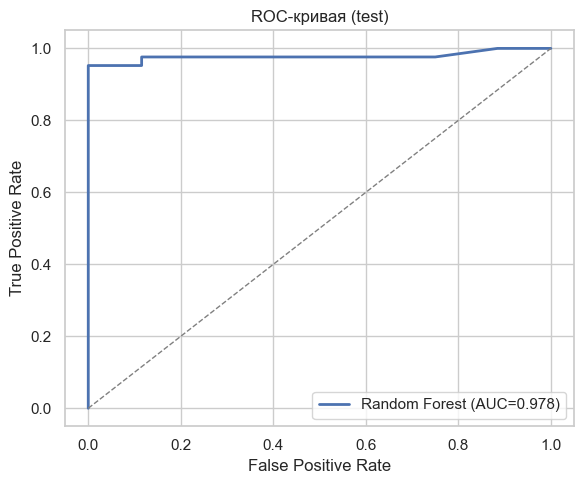

In [7]:
fpr, tpr, _ = roc_curve(y_test, p_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC={auc_test:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

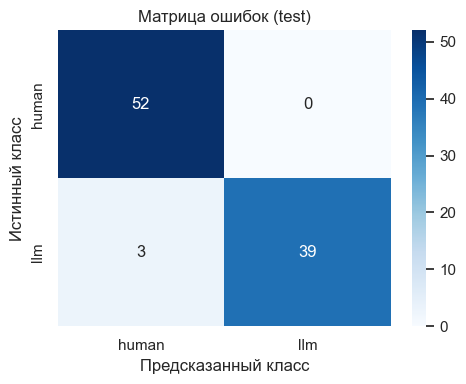

In [8]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["human", "llm"],
    yticklabels=["human", "llm"],
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (test)")
plt.tight_layout()
plt.show()

In [9]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp.head(12)

lexical_diversity          0.390582
repetition_score           0.292585
word_length_variation      0.135717
stop_word_ratio            0.056690
burstiness                 0.048382
text_entropy               0.028877
punctuation_ratio          0.023701
average_sentence_length    0.015641
unicode                    0.007826
perplexity                 0.000000
dtype: float64

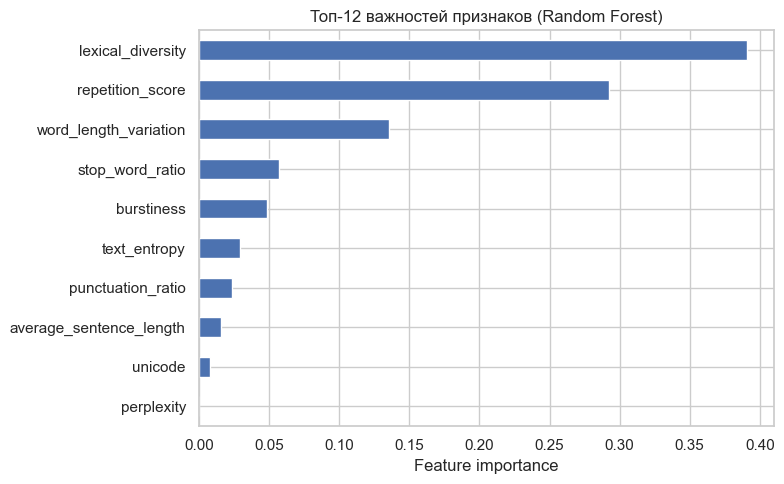

In [10]:
plt.figure(figsize=(8, 5))
imp.head(12).sort_values().plot(kind="barh")
plt.title("Топ-12 важностей признаков (Random Forest)")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [11]:
# Внешняя проверка на master (если файл есть)
master_result = None

if MASTER_EVAL_CSV.exists():
    df_master = pd.read_csv(MASTER_EVAL_CSV)
    X_master = df_master[FEATURES]
    y_master = df_master["label"].astype(int)

    p_master = rf.predict_proba(X_master)[:, 1]
    y_master_pred = (p_master >= 0.5).astype(int)

    auc_master = roc_auc_score(y_master, p_master)
    cm_master = confusion_matrix(y_master, y_master_pred, labels=[0, 1])
    report_master = classification_report(
        y_master,
        y_master_pred,
        labels=[0, 1],
        target_names=["human", "llm"],
        output_dict=True,
    )

    master_result = {
        "n_rows": int(len(df_master)),
        "n_human": int((y_master == 0).sum()),
        "n_llm": int((y_master == 1).sum()),
        "roc_auc": float(auc_master),
        "confusion_matrix": cm_master.tolist(),
        "classification_report": report_master,
    }

    print(f"ROC-AUC (master): {auc_master:.4f}")
    print("Confusion matrix [[tn, fp], [fn, tp]]:", cm_master.tolist())
    print(classification_report(y_master, y_master_pred, labels=[0, 1], target_names=["human", "llm"]))
else:
    print("MASTER_EVAL_CSV не найден, внешняя проверка пропущена")

ROC-AUC (master): 0.9070
Confusion matrix [[tn, fp], [fn, tp]]: [[97, 4], [16, 28]]
              precision    recall  f1-score   support

       human       0.86      0.96      0.91       101
         llm       0.88      0.64      0.74        44

    accuracy                           0.86       145
   macro avg       0.87      0.80      0.82       145
weighted avg       0.86      0.86      0.86       145



In [12]:
result = {
    "model": "random_forest",
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "feature_names": FEATURES,
    "train_test": {
        "n_total": int(len(df)),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "roc_auc": float(auc_test),
        "confusion_matrix": cm_test.tolist(),
        "classification_report": report_test,
    },
    "master_eval": master_result,
}

OUT_JSON.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("Сохранено:", OUT_JSON)

Сохранено: /Users/herman/Documents/GitHub/llm-audit-service/ml/catboost/rf_metrics_notebook.json
